# **EM + EM25**

In [1]:
import os
import json
import math
import ast
import re
import pandas as pd
from datetime import datetime
from evaluate import load

# ============================================================
# 0) Paths + Load df_results
# ============================================================

output_dir = "arabicaqa_rag_results/predictions"

df_results_name = "comparison_llama_mistral_command_1000.csv"
df_results_path = os.path.join(output_dir, df_results_name)

os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(df_results_path):
    raise FileNotFoundError(f"df_results not found at: {df_results_path}")

df_results = pd.read_csv(df_results_path)

print("\n" + "=" * 80)
print(" CALCULATING OFFICIAL SCORES (EM25 FIXED)")
print("=" * 80)
print(f"Loaded df_results: {df_results_path}")
print(f"Rows: {len(df_results):,}")
print(f"Columns: {list(df_results.columns)}")

# ============================================================
# 1) Detect models dynamically
# ============================================================

prediction_prefix = "predicted_answer_"

model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

if not model_keys:
    raise KeyError("No predicted_answer_* columns found in df_results.")

print("\nDetected models:")
for m in model_keys:
    print(f" - {m}")

required_cols = ["correct_answers", "is_impossible"]
missing = [c for c in required_cols if c not in df_results.columns]

if missing:
    raise KeyError(f"Missing required columns in df_results: {missing}")

# ============================================================
# 2) Arabic normalization + Abstention definitions
# ============================================================

NO_ANSWER = "غير موجود في السياق"

def normalize_arabic_text(s):
    if s is None:
        return ""

    if isinstance(s, float) and math.isnan(s):
        return ""

    s = str(s).strip()

    # Remove Arabic diacritics
    s = re.sub(r"[\u064B-\u065F\u0670]", "", s)

    # Normalize Arabic variants
    s = re.sub(r"[إأآا]", "ا", s)
    s = re.sub(r"ى", "ي", s)
    s = re.sub(r"ؤ", "و", s)
    s = re.sub(r"ئ", "ي", s)
    s = re.sub(r"ة", "ه", s)

    # Remove tatweel
    s = re.sub(r"ـ", "", s)

    # Remove punctuation/symbols except Arabic, English, digits, and spaces
    s = re.sub(r"[^\w\s\u0600-\u06FF]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s


def normalize_pred(pred):
    if pred is None:
        return ""

    if isinstance(pred, float) and math.isnan(pred):
        return ""

    return str(pred).strip()


# Flexible abstention patterns:
# These detect whether the model behaviorally abstained,
# even if it did not exactly match the canonical reference.
NO_ANSWER_PATTERNS = [
    # Generic absence
    r"غير\s+موجود",
    r"غير\s+مذكور",
    r"غير\s+متوفر",
    r"ليس\s+مذكور(?:ا)?",
    r"لا\s+يوجد",
    r"لا\s+توجد",
    r"لا\s+تتوفر",

    # Context-related abstentions
    r"لا\s+يحتوي\s+السياق",
    r"لم\s+يكن\s+(?:موجود(?:ا)?\s+)?في\s+السياق",
    r"غير\s+موجود\s+في\s+السياق",
    r"غير\s+مذكور\s+في\s+السياق",

    # Information unavailable
    r"لا\s+توجد\s+معلومات",
    r"المعلومات\s+غير\s+متوفر(?:ه|ة)",
    r"لا\s+يوجد\s+جواب",
    r"لا\s+يوجد\s+اجابه",

    # Cannot answer / determine / find
    r"لا\s+يمكن(?:ني)?\s+ال?اجابه",
    r"لا\s+يمكن(?:ني)?\s+تحديد",
    r"لا\s+يمكن(?:ني)?\s+العثور",

    # Explicit uncertainty
    r"لا\s+اعلم",
    r"لا\s+اعرف",

    # English fallbacks
    r"not\s+found",
    r"not\s+mentioned",
    r"not\s+available",
    r"not\s+present\s+in\s+the\s+context",
    r"cannot\s+answer",
    r"i\s+do\s+not\s+know",
]


def is_flexible_no_answer(text):
    t = normalize_arabic_text(text)

    if not t:
        return False

    return any(re.search(pattern, t) for pattern in NO_ANSWER_PATTERNS)


def is_strict_canonical_no_answer(text):
    """
    Strict canonical abstention:
    True only when the prediction exactly matches the canonical no-answer label
    after Arabic normalization.
    """
    pred_norm = normalize_arabic_text(text)
    canonical_norm = normalize_arabic_text(NO_ANSWER)

    return pred_norm == canonical_norm

# ============================================================
# 3) Parse correct_answers from CSV
# ============================================================

def parse_maybe_list(x):
    if x is None:
        return x

    if isinstance(x, float) and math.isnan(x):
        return x

    if isinstance(x, str):
        s = x.strip()

        if s.startswith("[") and s.endswith("]"):
            try:
                return json.loads(s)
            except Exception:
                pass

            try:
                return ast.literal_eval(s)
            except Exception:
                return x

        return x

    return x


def force_list(x):
    if x is None:
        return [NO_ANSWER]

    if isinstance(x, float) and math.isnan(x):
        return [NO_ANSWER]

    if isinstance(x, (list, tuple)):
        cleaned = []

        for item in x:
            if item is None:
                continue

            if isinstance(item, float) and math.isnan(item):
                continue

            item = str(item).strip()

            if item:
                cleaned.append(item)

        return cleaned if cleaned else [NO_ANSWER]

    s = str(x).strip()

    return [s] if s else [NO_ANSWER]


df_results["correct_answers"] = (
    df_results["correct_answers"]
    .apply(parse_maybe_list)
    .apply(force_list)
)

df_results["is_impossible"] = df_results["is_impossible"].astype(bool)

# ============================================================
# 4) Load official EM metric + REAL EM25 (character-prefix-strip)
# ============================================================

em_metric = load("exact_match")

# NOTE (fix): evaluate.load("exact_match", "exact_match_25") does NOT
# implement any distinct behavior -- "exact_match_25" is just an unused
# config_name string; HF's exact_match metric has no such config, so it
# silently falls back to standard exact_match. That made EM25 identical
# to EM by construction, not by data. Replaced below with a real,
# self-contained EM25 implementation matching the paper's description:
# "matching the reference after stripping the first 25 characters,
# accommodating verbose prefixes common in instruction-tuned Arabic models."


def compute_em25_single(pred_norm, ref_norm, max_strip=25):
    """
    Character-prefix-strip EM25.

    Tries removing 0..max_strip characters from the FRONT of the
    (already normalized) prediction, and returns 1 if any resulting
    suffix exactly equals the (already normalized) reference, else 0.

    This operationalizes "allowing limited lexical variation" via
    tolerance for verbose leading text (e.g. "الإجابة هي:", "بناءً على
    السياق،") without permitting arbitrary partial-credit matching.
    """
    if not ref_norm:
        return 0

    for k in range(0, max_strip + 1):
        if pred_norm[k:] == ref_norm:
            return 1

    return 0


def normalize_refs(refs):
    if refs is None:
        return [NO_ANSWER]

    if isinstance(refs, float) and math.isnan(refs):
        return [NO_ANSWER]

    if isinstance(refs, str):
        s = refs.strip()
        return [s] if s else [NO_ANSWER]

    if isinstance(refs, (list, tuple)):
        if len(refs) == 1 and isinstance(refs[0], (list, tuple)):
            refs = refs[0]

        cleaned = []

        for r in refs:
            if r is None:
                continue

            if isinstance(r, float) and math.isnan(r):
                continue

            r = str(r).strip()

            if r:
                cleaned.append(r)

        return cleaned if cleaned else [NO_ANSWER]

    s = str(refs).strip()

    return [s] if s else [NO_ANSWER]


def compute_scores(predictions, references_list):
    em_scores = []
    em25_scores = []

    for pred, refs in zip(predictions, references_list):
        pred_norm = normalize_arabic_text(normalize_pred(pred))
        refs_norm = [normalize_arabic_text(r) for r in normalize_refs(refs)]

        best_em = max(
            em_metric.compute(
                predictions=[pred_norm],
                references=[ref_norm],
                ignore_case=True,
                ignore_punctuation=True
            )["exact_match"]
            for ref_norm in refs_norm
        )

        best_em25 = max(
            compute_em25_single(pred_norm, ref_norm, max_strip=25)
            for ref_norm in refs_norm
        )

        em_scores.append(best_em)
        em25_scores.append(best_em25)

    avg_em = round(sum(em_scores) / len(em_scores) * 100, 2) if em_scores else 0.0
    avg_em25 = round(sum(em25_scores) / len(em25_scores) * 100, 2) if em25_scores else 0.0

    return avg_em, avg_em25

# ============================================================
# 5) Strict + Flexible abstention stats
# ============================================================

def abstention_stats(pred_series, detector_fn):
    flags = pred_series.fillna("").apply(detector_fn)

    correct_count = int(flags.sum())
    total = int(len(flags))
    accuracy = round((correct_count / total) * 100, 2) if total else 0.0

    return correct_count, total, accuracy


def flexible_overall_scores(df, pred_col):
    """
    Overall flexible score:
    - Answerable questions: EM / EM25 against gold answers.
    - Unanswerable questions: correct if prediction matches any abstention pattern.
    """
    overall_em_scores = []
    overall_em25_scores = []

    for _, row in df.iterrows():
        pred = row[pred_col]

        if row["is_impossible"]:
            score = float(is_flexible_no_answer(pred))
            overall_em_scores.append(score)
            overall_em25_scores.append(score)
        else:
            em, em25 = compute_scores(
                [pred],
                [row["correct_answers"]]
            )
            overall_em_scores.append(em / 100)
            overall_em25_scores.append(em25 / 100)

    overall_em = round(sum(overall_em_scores) / len(overall_em_scores) * 100, 2)
    overall_em25 = round(sum(overall_em25_scores) / len(overall_em25_scores) * 100, 2)

    return overall_em, overall_em25


def strict_overall_scores(df, pred_col):
    """
    Overall strict score:
    - Answerable questions: EM / EM25 against gold answers.
    - Unanswerable questions: correct only if prediction exactly matches
      the canonical abstention label after normalization.
    """
    overall_em_scores = []
    overall_em25_scores = []

    for _, row in df.iterrows():
        pred = row[pred_col]

        if row["is_impossible"]:
            score = float(is_strict_canonical_no_answer(pred))
            overall_em_scores.append(score)
            overall_em25_scores.append(score)
        else:
            em, em25 = compute_scores(
                [pred],
                [row["correct_answers"]]
            )
            overall_em_scores.append(em / 100)
            overall_em25_scores.append(em25 / 100)

    overall_em = round(sum(overall_em_scores) / len(overall_em_scores) * 100, 2)
    overall_em25 = round(sum(overall_em25_scores) / len(overall_em25_scores) * 100, 2)

    return overall_em, overall_em25

# ============================================================
# 6) Compute scores for all detected models
# ============================================================

ans_mask = df_results["is_impossible"] == False
un_mask = df_results["is_impossible"] == True

df_ans = df_results[ans_mask].copy()
df_un = df_results[un_mask].copy()

summary_rows = []

summary = {
    "date": datetime.now().isoformat(),
    "dataset": "ArabicaQA fixed 1,000-question sample",
    "df_results_path": df_results_path,
    "canonical_no_answer_label": NO_ANSWER,
    "em25_definition": "Character-prefix-strip EM25: prediction matches a reference after stripping 0-25 leading characters (post-normalization).",
    "strict_policy": "Strict canonical abstention: unanswerable questions are correct only if the prediction exactly matches the canonical no-answer label after normalization.",
    "flexible_policy": "Flexible abstention: unanswerable questions are correct if the prediction matches any recognized abstention pattern.",
    "counts": {
        "total": int(len(df_results)),
        "answerable": int(len(df_ans)),
        "unanswerable": int(len(df_un)),
    },
    "models": {}
}

for model_key in model_keys:
    pred_col = f"predicted_answer_{model_key}"
    latency_col = f"latency_sec_{model_key}"

    preds_ans = df_ans[pred_col].tolist()

    # Answerable only
    answerable_em, answerable_em25 = compute_scores(
        preds_ans,
        df_ans["correct_answers"].tolist()
    )

    # Strict overall:
    # - answerable: canonical EM / EM25
    # - unanswerable: exact canonical abstention only
    strict_overall_em, strict_overall_em25 = strict_overall_scores(
        df_results,
        pred_col
    )

    # Flexible overall:
    # - answerable: canonical EM / EM25
    # - unanswerable: any recognized abstention phrase
    flexible_overall_em, flexible_overall_em25 = flexible_overall_scores(
        df_results,
        pred_col
    )

    # Strict abstention on unanswerable only
    strict_count, unanswerable_total, strict_acc = abstention_stats(
        df_un[pred_col],
        is_strict_canonical_no_answer
    )

    # Flexible abstention on unanswerable only
    flexible_count, _, flexible_acc = abstention_stats(
        df_un[pred_col],
        is_flexible_no_answer
    )

    # Incorrect abstention on answerable questions
    answerable_abstention_count, answerable_total, answerable_abstention_rate = abstention_stats(
        df_ans[pred_col],
        is_flexible_no_answer
    )

    # Errors
    n_errors = int((df_results[pred_col].fillna("") == "ERROR").sum())

    # Latency, if available
    if latency_col in df_results.columns:
        latency_mean = round(float(df_results[latency_col].mean()), 4)
        latency_median = round(float(df_results[latency_col].median()), 4)
        latency_p95 = round(float(df_results[latency_col].quantile(0.95)), 4)
        latency_std = round(float(df_results[latency_col].std()), 4)
    else:
        latency_mean = None
        latency_median = None
        latency_p95 = None
        latency_std = None

    row = {
        "model": model_key,

        # Overall scores
        "strict_overall_em": strict_overall_em,
        "strict_overall_em25": strict_overall_em25,
        "flexible_overall_em": flexible_overall_em,
        "flexible_overall_em25": flexible_overall_em25,

        # Answerable generation quality
        "answerable_em": answerable_em,
        "answerable_em25": answerable_em25,

        # Unanswerable abstention behavior
        "strict_abstention_count": strict_count,
        "flexible_abstention_count": flexible_count,
        "unanswerable_total": unanswerable_total,
        "strict_abstention_accuracy": strict_acc,
        "flexible_abstention_accuracy": flexible_acc,

        # Wrong abstention on answerable questions
        "answerable_abstention_count": answerable_abstention_count,
        "answerable_total": answerable_total,
        "answerable_abstention_rate": answerable_abstention_rate,

        # Runtime / errors
        "errors": n_errors,
        "latency_mean_sec": latency_mean,
        "latency_median_sec": latency_median,
        "latency_p95_sec": latency_p95,
        "latency_std_sec": latency_std,
    }

    summary_rows.append(row)
    summary["models"][model_key] = row

df_summary = pd.DataFrame(summary_rows)

# Sort by flexible overall EM25 because this is usually the fairer behavioral metric
df_summary = df_summary.sort_values(
    by="flexible_overall_em25",
    ascending=False
).reset_index(drop=True)

winner = df_summary.iloc[0]["model"]
winner_score = df_summary.iloc[0]["flexible_overall_em25"]

summary["winner_by_flexible_overall_em25"] = {
    "model": str(winner),
    "flexible_overall_em25": float(winner_score),
}

# ============================================================
# 7) Print results
# ============================================================

print("\n" + "=" * 120)
print(" FINAL RESULTS: STRICT + FLEXIBLE ABSTENTION (EM25 CORRECTED)")
print("=" * 120)

display_cols = [
    "model",

    "strict_overall_em",
    "strict_overall_em25",
    "flexible_overall_em",
    "flexible_overall_em25",

    "answerable_em",
    "answerable_em25",

    "strict_abstention_accuracy",
    "flexible_abstention_accuracy",

    "strict_abstention_count",
    "flexible_abstention_count",
    "unanswerable_total",

    "answerable_abstention_rate",
    "answerable_abstention_count",
    "answerable_total",

    "latency_mean_sec",
    "latency_median_sec",
    "latency_p95_sec",
    "errors",
]

print(df_summary[display_cols].to_string(index=False))

print("\n" + "=" * 120)
print(" WINNER")
print("=" * 120)
print(f"Winner by Flexible Overall EM25: {winner} ({winner_score:.2f}%)")

# ============================================================
# 8) Save results  (filenames tagged "_corrected")
# ============================================================

summary_csv_path = os.path.join(
    output_dir,
    "final_scores_strict_and_flexible_abstention_corrected.csv"
)

summary_json_path = os.path.join(
    output_dir,
    "final_scores_strict_and_flexible_abstention_corrected.json"
)

summary_txt_path = os.path.join(
    output_dir,
    "FINAL_SCORES_Strict_and_Flexible_Abstention_corrected.txt"
)

summary_md_path = os.path.join(
    output_dir,
    "README_Strict_and_Flexible_Abstention_corrected.md"
)

df_summary.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

with open(summary_txt_path, "w", encoding="utf-8") as f:
    f.write("ArabicaQA RAG Evaluation – Strict and Flexible Abstention Results (EM25 corrected)\n")
    f.write("=" * 100 + "\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write(f"Results file: {df_results_path}\n")
    f.write(f"Total questions: {len(df_results):,}\n")
    f.write(f"Answerable: {len(df_ans):,}\n")
    f.write(f"Unanswerable: {len(df_un):,}\n")
    f.write(f"Canonical no-answer label: {NO_ANSWER}\n\n")
    f.write("EM25 definition (corrected):\n")
    f.write("Character-prefix-strip EM25: prediction matches a reference after stripping 0-25 leading characters (post-normalization).\n\n")
    f.write("Strict policy:\n")
    f.write("Unanswerable questions are correct only if the prediction exactly matches the canonical no-answer label after normalization.\n\n")
    f.write("Flexible policy:\n")
    f.write("Unanswerable questions are correct if the prediction matches any recognized abstention pattern.\n\n")
    f.write(df_summary.to_string(index=False))
    f.write("\n\n")
    f.write(f"Winner by Flexible Overall EM25: {winner} ({winner_score:.2f}%)\n")

markdown_table = df_summary.to_markdown(index=False)

with open(summary_md_path, "w", encoding="utf-8") as f:
    f.write("# ArabicaQA RAG Evaluation – Strict and Flexible Abstention (EM25 corrected)\n\n")
    f.write(f"Evaluation subset: **{len(df_results):,} questions**  \n")
    f.write(f"Answerable: **{len(df_ans):,}**  \n")
    f.write(f"Unanswerable: **{len(df_un):,}**  \n")
    f.write(f"Canonical no-answer label: **{NO_ANSWER}**  \n\n")

    f.write("## Evaluation Policies\n\n")
    f.write("**EM25 (corrected):** character-prefix-strip match — prediction matches a reference after stripping 0-25 leading characters (post-normalization).  \n")
    f.write("**Strict abstention / canonical EM:** unanswerable questions are correct only if the prediction exactly matches the canonical no-answer label after normalization.  \n")
    f.write("**Flexible abstention / abstention accuracy:** unanswerable questions are correct if the prediction matches any recognized abstention pattern.  \n\n")

    f.write("## Final Scores\n\n")
    f.write(markdown_table)
    f.write("\n\n")
    f.write(f"**Winner by Flexible Overall EM25:** {winner} ({winner_score:.2f}%)\n")

print("\nAll results saved successfully!")
print(f"CSV  → {summary_csv_path}")
print(f"JSON → {summary_json_path}")
print(f"TXT  → {summary_txt_path}")
print(f"MD   → {summary_md_path}")

c:\Users\Zohoor Almalki\Projects\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



 CALCULATING OFFICIAL SCORES (EM25 FIXED)
Loaded df_results: arabicaqa_rag_results/predictions\comparison_llama_mistral_command_1000.csv
Rows: 1,000
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_command', 'latency_sec_command', 'error_command', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral']

Detected models:
 - command
 - llama
 - mistral

 FINAL RESULTS: STRICT + FLEXIBLE ABSTENTION (EM25 CORRECTED)
  model  strict_overall_em  strict_overall_em25  flexible_overall_em  flexible_overall_em25  answerable_em  answerable_em25  strict_abstention_accuracy  flexible_abstention_accuracy  strict_abstention_count  flexible_abstention_count  unanswerable_total  answerable_abstention_rate  answerable_abstention_count  answerable_total  latency_

## **Statistical significance analysis**

In [2]:
import numpy as np
import pandas as pd
import math
import ast
import re
import os
from collections import Counter
from itertools import combinations

# ============================================================
# 0) Paths + Load df_results
# ============================================================

predictions_dir = "arabicaqa_rag_results/predictions"

df_results_name = "comparison_llama_mistral_command_1000.csv"
df_results_path = os.path.join(predictions_dir, df_results_name)

if not os.path.exists(df_results_path):
    raise FileNotFoundError(f"df_results not found at: {df_results_path}")

df_results = pd.read_csv(df_results_path)

print("\nLoaded:", df_results_path)
print("Rows:", len(df_results))
print("Columns:", list(df_results.columns))

# ============================================================
# 1) Model name mapping
# ============================================================

MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "llama-3-8b-instruct",
    "mistral": "mistral-7b-instruct-v0.1",
}

# ============================================================
# 2) Detect models dynamically from prediction columns
# ============================================================

prediction_prefix = "predicted_answer_"

detected_model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

if len(detected_model_keys) < 2:
    raise ValueError("At least two predicted_answer_* columns are required for paired comparisons.")

model_key_to_display = {
    key: MODEL_DISPLAY_NAMES.get(key, key)
    for key in detected_model_keys
}

model_names = [model_key_to_display[key] for key in detected_model_keys]

print("\nDetected models:")
for key in detected_model_keys:
    print(f" - {key} -> {model_key_to_display[key]}")

required_cols = ["correct_answers", "is_impossible"]
missing = [c for c in required_cols if c not in df_results.columns]

if missing:
    raise KeyError(f"Missing required columns: {missing}")

# ============================================================
# 3) Bootstrap settings
# ============================================================

RANDOM_SEED = 42
N_BOOT = 10000
ALPHA = 0.05

rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# 4) Helpers
# ============================================================

NO_ANSWER = "غير موجود في السياق"


def safe_str(x):
    if x is None:
        return ""

    if isinstance(x, float) and math.isnan(x):
        return ""

    return str(x)


def parse_correct_answers(x):
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        try:
            parsed = ast.literal_eval(s)

            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]

            return [str(parsed).strip()] if str(parsed).strip() else []

        except Exception:
            return [s]

    return []


def normalize_arabic_text(s):
    s = safe_str(s).strip()

    # Remove Arabic diacritics
    s = re.sub(r"[\u064B-\u065F\u0670]", "", s)

    # Normalize Arabic variants
    s = re.sub(r"[إأآا]", "ا", s)
    s = re.sub(r"ى", "ي", s)
    s = re.sub(r"ؤ", "و", s)
    s = re.sub(r"ئ", "ي", s)
    s = re.sub(r"ة", "ه", s)

    # Remove tatweel
    s = re.sub(r"ـ", "", s)

    # Remove punctuation/symbols except Arabic, English, digits, and spaces
    s = re.sub(r"[^\w\s\u0600-\u06FF]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s


# Flexible abstention patterns:
# Same logic as the previous final-score script.
NO_ANSWER_PATTERNS = [
    # Generic absence
    r"غير\s+موجود",
    r"غير\s+مذكور",
    r"غير\s+متوفر",
    r"ليس\s+مذكور(?:ا)?",
    r"لا\s+يوجد",
    r"لا\s+توجد",
    r"لا\s+تتوفر",

    # Context-related abstentions
    r"لا\s+يحتوي\s+السياق",
    r"لم\s+يكن\s+(?:موجود(?:ا)?\s+)?في\s+السياق",
    r"غير\s+موجود\s+في\s+السياق",
    r"غير\s+مذكور\s+في\s+السياق",

    # Information unavailable
    r"لا\s+توجد\s+معلومات",
    r"المعلومات\s+غير\s+متوفر(?:ه|ة)",
    r"لا\s+يوجد\s+جواب",
    r"لا\s+يوجد\s+اجابه",

    # Cannot answer / determine / find
    r"لا\s+يمكن(?:ني)?\s+ال?اجابه",
    r"لا\s+يمكن(?:ني)?\s+تحديد",
    r"لا\s+يمكن(?:ني)?\s+العثور",

    # Explicit uncertainty
    r"لا\s+اعلم",
    r"لا\s+اعرف",

    # English fallbacks
    r"not\s+found",
    r"not\s+mentioned",
    r"not\s+available",
    r"not\s+present\s+in\s+the\s+context",
    r"cannot\s+answer",
    r"i\s+do\s+not\s+know",
]


def is_flexible_no_answer(pred):
    p = normalize_arabic_text(pred)

    if not p:
        return False

    return any(re.search(pattern, p) for pattern in NO_ANSWER_PATTERNS)


def is_strict_canonical_no_answer(pred):
    pred_norm = normalize_arabic_text(pred)
    canonical_norm = normalize_arabic_text(NO_ANSWER)

    return pred_norm == canonical_norm


def token_f1(pred, gold):
    pred_tokens = normalize_arabic_text(pred).split()
    gold_tokens = normalize_arabic_text(gold).split()

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0

    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)

    return 2 * precision * recall / (precision + recall)


def exact_match(pred, gold):
    return float(normalize_arabic_text(pred) == normalize_arabic_text(gold))


# ------------------------------------------------------------
# NEW (fix): character-prefix-strip EM25, matching the
# implementation now used in the main scoring cell.
# Accepts a prediction as correct if it exactly matches the
# gold answer after stripping 0..max_strip leading characters
# (post-normalization), tolerating verbose response prefixes.
# Previously this cell had NO independent EM25 implementation,
# so the Table 3 "Ans EM-25" bootstrap CI was in effect a copy
# of the "Ans EM" CI (valid only because EM25 == EM per-question
# under the old, broken evaluate.load() config). This function
# and the columns/metrics below restore a genuine, separately
# bootstrapped EM25 estimate.
# ------------------------------------------------------------
def exact_match_25(pred, gold, max_strip=25):
    pred_norm = normalize_arabic_text(pred)
    gold_norm = normalize_arabic_text(gold)

    if not gold_norm:
        return 0.0

    for k in range(0, max_strip + 1):
        if pred_norm[k:] == gold_norm:
            return 1.0

    return 0.0


def max_over_gold(metric_fn, pred, golds):
    if not golds:
        return 0.0

    return max(metric_fn(pred, g) for g in golds)

# ============================================================
# 5) Prepare data
# ============================================================

df_boot = df_results.copy()

df_boot["correct_answers"] = df_boot["correct_answers"].apply(parse_correct_answers)
df_boot["is_impossible"] = df_boot["is_impossible"].astype(bool)

# ============================================================
# 6) Per-question metric columns for each model
# ============================================================

for original_key in detected_model_keys:
    model_name = model_key_to_display[original_key]
    pred_col = f"predicted_answer_{original_key}"

    if pred_col not in df_boot.columns:
        raise KeyError(f"Missing prediction column: {pred_col}")

    # Answerable EM only
    df_boot[f"{model_name}_em_ans"] = df_boot.apply(
        lambda r: max_over_gold(exact_match, r[pred_col], r["correct_answers"])
        if not r["is_impossible"] else np.nan,
        axis=1
    )

    # NEW: Answerable EM25 only
    df_boot[f"{model_name}_em25_ans"] = df_boot.apply(
        lambda r: max_over_gold(exact_match_25, r[pred_col], r["correct_answers"])
        if not r["is_impossible"] else np.nan,
        axis=1
    )

    # Answerable Token-F1 only
    df_boot[f"{model_name}_f1_ans"] = df_boot.apply(
        lambda r: max_over_gold(token_f1, r[pred_col], r["correct_answers"])
        if not r["is_impossible"] else np.nan,
        axis=1
    )

    # Strict abstention on unanswerable only
    df_boot[f"{model_name}_strict_noans_acc"] = df_boot.apply(
        lambda r: float(is_strict_canonical_no_answer(r[pred_col]))
        if r["is_impossible"] else np.nan,
        axis=1
    )

    # Flexible abstention on unanswerable only
    df_boot[f"{model_name}_flexible_noans_acc"] = df_boot.apply(
        lambda r: float(is_flexible_no_answer(r[pred_col]))
        if r["is_impossible"] else np.nan,
        axis=1
    )

    # Strict overall (EM-based):
    # - answerable: EM against gold answers
    # - unanswerable: exact canonical abstention only
    df_boot[f"{model_name}_strict_overall_acc"] = df_boot.apply(
        lambda r: (
            float(is_strict_canonical_no_answer(r[pred_col]))
            if r["is_impossible"]
            else max_over_gold(exact_match, r[pred_col], r["correct_answers"])
        ),
        axis=1
    )

    # NEW: Strict overall (EM25-based)
    df_boot[f"{model_name}_strict_overall_acc25"] = df_boot.apply(
        lambda r: (
            float(is_strict_canonical_no_answer(r[pred_col]))
            if r["is_impossible"]
            else max_over_gold(exact_match_25, r[pred_col], r["correct_answers"])
        ),
        axis=1
    )

    # Flexible overall (EM-based):
    # - answerable: EM against gold answers
    # - unanswerable: any valid abstention phrase
    df_boot[f"{model_name}_flexible_overall_acc"] = df_boot.apply(
        lambda r: (
            float(is_flexible_no_answer(r[pred_col]))
            if r["is_impossible"]
            else max_over_gold(exact_match, r[pred_col], r["correct_answers"])
        ),
        axis=1
    )

    # NEW: Flexible overall (EM25-based)
    df_boot[f"{model_name}_flexible_overall_acc25"] = df_boot.apply(
        lambda r: (
            float(is_flexible_no_answer(r[pred_col]))
            if r["is_impossible"]
            else max_over_gold(exact_match_25, r[pred_col], r["correct_answers"])
        ),
        axis=1
    )

    # Incorrect abstention on answerable questions
    df_boot[f"{model_name}_answerable_abstention_rate"] = df_boot.apply(
        lambda r: float(is_flexible_no_answer(r[pred_col]))
        if not r["is_impossible"] else np.nan,
        axis=1
    )

# ============================================================
# 7) Bootstrap functions
# ============================================================

def bootstrap_ci(values, n_boot=10000, alpha=0.05):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    n = len(values)

    if n == 0:
        return np.nan, np.nan, np.nan

    boot_means = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_means[b] = values[idx].mean()

    mean = values.mean()
    lower = np.percentile(boot_means, 100 * alpha / 2)
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))

    return mean, lower, upper


def bootstrap_paired_diff_ci(values_a, values_b, n_boot=10000, alpha=0.05):
    values_a = np.asarray(values_a, dtype=float)
    values_b = np.asarray(values_b, dtype=float)

    mask = ~np.isnan(values_a) & ~np.isnan(values_b)

    values_a = values_a[mask]
    values_b = values_b[mask]

    diffs = values_a - values_b
    n = len(diffs)

    if n == 0:
        return np.nan, np.nan, np.nan, np.nan

    boot_diffs = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_diffs[b] = diffs[idx].mean()

    observed_diff = diffs.mean()

    lower = np.percentile(boot_diffs, 100 * alpha / 2)
    upper = np.percentile(boot_diffs, 100 * (1 - alpha / 2))

    p_value = 2 * min(
        np.mean(boot_diffs <= 0),
        np.mean(boot_diffs >= 0)
    )

    p_value = min(p_value, 1.0)

    return observed_diff, lower, upper, p_value

# ============================================================
# 8) Generate model-level CI table
# ============================================================

metrics = {
    "Strict Overall Accuracy / EM": "strict_overall_acc",
    "Strict Overall Accuracy / EM25": "strict_overall_acc25",       # NEW
    "Flexible Overall Accuracy / EM": "flexible_overall_acc",
    "Flexible Overall Accuracy / EM25": "flexible_overall_acc25",    # NEW

    "Answerable EM": "em_ans",
    "Answerable EM25": "em25_ans",                                   # NEW
    "Answerable Token-F1": "f1_ans",

    "Strict Unanswerable Abstention Accuracy": "strict_noans_acc",
    "Flexible Unanswerable Abstention Accuracy": "flexible_noans_acc",

    "Answerable Abstention Rate": "answerable_abstention_rate",
}

model_ci_rows = []

for metric_name, suffix in metrics.items():
    for model_name in model_names:
        col = f"{model_name}_{suffix}"

        mean, low, high = bootstrap_ci(
            df_boot[col].values,
            n_boot=N_BOOT,
            alpha=ALPHA
        )

        model_ci_rows.append({
            "metric": metric_name,
            "model": model_name,
            "mean": mean,
            "ci_low": low,
            "ci_high": high,
            "n_boot": N_BOOT,
        })

df_model_ci = pd.DataFrame(model_ci_rows)

# ============================================================
# 9) Generate paired comparison table for all model pairs
# ============================================================

pairwise_rows = []

for metric_name, suffix in metrics.items():
    for model_a, model_b in combinations(model_names, 2):
        col_a = f"{model_a}_{suffix}"
        col_b = f"{model_b}_{suffix}"

        diff, low, high, p_value = bootstrap_paired_diff_ci(
            df_boot[col_a].values,
            df_boot[col_b].values,
            n_boot=N_BOOT,
            alpha=ALPHA
        )

        pairwise_rows.append({
            "metric": metric_name,
            "model_a": model_a,
            "model_b": model_b,
            "diff_a_minus_b": diff,
            "diff_95ci_low": low,
            "diff_95ci_high": high,
            "bootstrap_p_value": p_value,
            "n_boot": N_BOOT,
        })

df_pairwise = pd.DataFrame(pairwise_rows)

# ============================================================
# 10) Optional latency CI table
# ============================================================

latency_rows = []

for original_key in detected_model_keys:
    model_name = model_key_to_display[original_key]
    latency_col = f"latency_sec_{original_key}"

    if latency_col in df_boot.columns:
        mean, low, high = bootstrap_ci(
            df_boot[latency_col].values,
            n_boot=N_BOOT,
            alpha=ALPHA
        )

        latency_rows.append({
            "model": model_name,
            "latency_mean_sec": mean,
            "latency_95ci_low_sec": low,
            "latency_95ci_high_sec": high,
            "latency_median_sec": float(df_boot[latency_col].median()),
            "latency_p95_sec": float(df_boot[latency_col].quantile(0.95)),
            "n_boot": N_BOOT,
        })

df_latency_ci = pd.DataFrame(latency_rows)

# ============================================================
# 11) Convert proportions to percentages
# ============================================================

df_model_ci_percent = df_model_ci.copy()
df_model_ci_percent[["mean", "ci_low", "ci_high"]] *= 100

df_pairwise_percent = df_pairwise.copy()
df_pairwise_percent[["diff_a_minus_b", "diff_95ci_low", "diff_95ci_high"]] *= 100

df_latency_ci_sec = df_latency_ci.copy()

# ============================================================
# 12) Add formatted CI columns for readability
# ============================================================

df_model_ci_percent["mean_95ci"] = df_model_ci_percent.apply(
    lambda r: f"{r['mean']:.2f} [{r['ci_low']:.2f}, {r['ci_high']:.2f}]",
    axis=1
)

df_pairwise_percent["diff_95ci_p"] = df_pairwise_percent.apply(
    lambda r: f"{r['diff_a_minus_b']:.2f} [{r['diff_95ci_low']:.2f}, {r['diff_95ci_high']:.2f}], p={r['bootstrap_p_value']:.4f}",
    axis=1
)

# ============================================================
# 13) Save outputs  (filenames tagged "_corrected" to preserve old run)
# ============================================================

output_dir = "arabicaqa_rag_results/statistical_analysis"
os.makedirs(output_dir, exist_ok=True)

model_ci_raw_path = os.path.join(
    output_dir,
    "bootstrap_model_ci_strict_and_flexible_raw_corrected.csv"
)

model_ci_pct_path = os.path.join(
    output_dir,
    "bootstrap_model_ci_strict_and_flexible_percent_corrected.csv"
)

pairwise_raw_path = os.path.join(
    output_dir,
    "bootstrap_pairwise_strict_and_flexible_raw_corrected.csv"
)

pairwise_pct_path = os.path.join(
    output_dir,
    "bootstrap_pairwise_strict_and_flexible_percent_corrected.csv"
)

latency_ci_path = os.path.join(
    output_dir,
    "bootstrap_latency_ci_sec_corrected.csv"
)

df_model_ci.to_csv(model_ci_raw_path, index=False, encoding="utf-8-sig")
df_model_ci_percent.to_csv(model_ci_pct_path, index=False, encoding="utf-8-sig")

df_pairwise.to_csv(pairwise_raw_path, index=False, encoding="utf-8-sig")
df_pairwise_percent.to_csv(pairwise_pct_path, index=False, encoding="utf-8-sig")

if not df_latency_ci_sec.empty:
    df_latency_ci_sec.to_csv(latency_ci_path, index=False, encoding="utf-8-sig")

print("\nSaved:")
print(f"- {model_ci_raw_path}")
print(f"- {model_ci_pct_path}")
print(f"- {pairwise_raw_path}")
print(f"- {pairwise_pct_path}")

if not df_latency_ci_sec.empty:
    print(f"- {latency_ci_path}")
else:
    print("- No latency columns found; skipped latency CI output.")

print("\nModel-level bootstrap CI (%):")
display(df_model_ci_percent.round(3))

print("\nPairwise bootstrap differences (%):")
display(df_pairwise_percent.round(3))

if not df_latency_ci_sec.empty:
    print("\nLatency bootstrap CI (seconds):")
    display(df_latency_ci_sec.round(3))


Loaded: arabicaqa_rag_results/predictions\comparison_llama_mistral_command_1000.csv
Rows: 1000
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_command', 'latency_sec_command', 'error_command', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral']

Detected models:
 - command -> command-r7b-12-2024
 - llama -> llama-3-8b-instruct
 - mistral -> mistral-7b-instruct-v0.1

Saved:
- arabicaqa_rag_results/statistical_analysis\bootstrap_model_ci_strict_and_flexible_raw_corrected.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_model_ci_strict_and_flexible_percent_corrected.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_pairwise_strict_and_flexible_raw_corrected.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_pairwise

,metric,model,mean,ci_low,ci_high,n_boot,mean_95ci
0,Strict Overall Accuracy / EM,command-r7b-12-2024,27.500,24.800,30.300,10000,"27.50 [24.80, 30.30]"
1,Strict Overall Accuracy / EM,llama-3-8b-instruct,5.400,4.000,6.800,10000,"5.40 [4.00, 6.80]"
2,Strict Overall Accuracy / EM,mistral-7b-instruct-v0.1,4.100,2.900,5.400,10000,"4.10 [2.90, 5.40]"
3,Strict Overall Accuracy / EM25,command-r7b-12-2024,28.000,25.200,30.800,10000,"28.00 [25.20, 30.80]"
4,Strict Overall Accuracy / EM25,llama-3-8b-instruct,6.300,4.800,7.800,10000,"6.30 [4.80, 7.80]"
5,Strict Overall Accuracy / EM25,mistral-7b-instruct-v0.1,4.200,3.000,5.500,10000,"4.20 [3.00, 5.50]"
6,Flexible Overall Accuracy / EM,command-r7b-12-2024,27.700,25.000,30.500,10000,"27.70 [25.00, 30.50]"
7,Flexible Overall Accuracy / EM,llama-3-8b-instruct,8.000,6.400,9.700,10000,"8.00 [6.40, 9.70]"
8,Flexible Overall Accuracy / EM,mistral-7b-instruct-v0.1,28.600,25.800,31.500,10000,"28.60 [25.80, 31.50]"
9,Flexible Overall Accuracy / EM25,command-r7b-12-2024,28.200,25.400,31.000,10000,"28.20 [25.40, 31.00]"



Pairwise bootstrap differences (%):


,metric,model_a,model_b,diff_a_minus_b,diff_95ci_low,diff_95ci_high,bootstrap_p_value,n_boot,diff_95ci_p
0,Strict Overall Accuracy / EM,command-r7b-12-2024,llama-3-8b-instruct,22.100,19.300,25.000,0.000,10000,"22.10 [19.30, 25.00], p=0.0000"
1,Strict Overall Accuracy / EM,command-r7b-12-2024,mistral-7b-instruct-v0.1,23.400,20.700,26.100,0.000,10000,"23.40 [20.70, 26.10], p=0.0000"
2,Strict Overall Accuracy / EM,llama-3-8b-instruct,mistral-7b-instruct-v0.1,1.300,-0.500,3.002,0.162,10000,"1.30 [-0.50, 3.00], p=0.1620"
3,Strict Overall Accuracy / EM25,command-r7b-12-2024,llama-3-8b-instruct,21.700,18.900,24.600,0.000,10000,"21.70 [18.90, 24.60], p=0.0000"
4,Strict Overall Accuracy / EM25,command-r7b-12-2024,mistral-7b-instruct-v0.1,23.800,21.000,26.600,0.000,10000,"23.80 [21.00, 26.60], p=0.0000"
5,Strict Overall Accuracy / EM25,llama-3-8b-instruct,mistral-7b-instruct-v0.1,2.100,0.300,4.000,0.024,10000,"2.10 [0.30, 4.00], p=0.0240"
6,Flexible Overall Accuracy / EM,command-r7b-12-2024,llama-3-8b-instruct,19.700,16.900,22.500,0.000,10000,"19.70 [16.90, 22.50], p=0.0000"
7,Flexible Overall Accuracy / EM,command-r7b-12-2024,mistral-7b-instruct-v0.1,-0.900,-3.702,2.000,0.562,10000,"-0.90 [-3.70, 2.00], p=0.5624"
8,Flexible Overall Accuracy / EM,llama-3-8b-instruct,mistral-7b-instruct-v0.1,-20.600,-23.600,-17.600,0.000,10000,"-20.60 [-23.60, -17.60], p=0.0000"
9,Flexible Overall Accuracy / EM25,command-r7b-12-2024,llama-3-8b-instruct,19.300,16.400,22.200,0.000,10000,"19.30 [16.40, 22.20], p=0.0000"



Latency bootstrap CI (seconds):


,model,latency_mean_sec,latency_95ci_low_sec,latency_95ci_high_sec,latency_median_sec,latency_p95_sec,n_boot
0,command-r7b-12-2024,1.512,1.484,1.539,1.340,2.546,10000
1,llama-3-8b-instruct,1.233,1.205,1.263,1.122,1.892,10000
2,mistral-7b-instruct-v0.1,6.445,6.257,6.643,6.019,10.231,10000


# **Answerable-Abstention Rate**

In [3]:
# ============================================================
# Answerable-Abstention Rate
# Measures how often a model incorrectly abstains
# on answerable questions.
#
# LOWER IS BETTER.
#
# This script computes BOTH:
#
# 1) Strict canonical abstention
#    Exact canonical abstention only.
#
# 2) Flexible abstention
#    Any recognized abstention phrase.
# ============================================================

import os
import re
import math
import numpy as np
import pandas as pd

# ============================================================
# 1) Bootstrap settings
# ============================================================

RANDOM_SEED = 42
N_BOOT = 10000
ALPHA = 0.05

rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# 2) Arabic normalization
# ============================================================

def normalize_arabic_text(s: str) -> str:
    if s is None:
        return ""

    if isinstance(s, float) and math.isnan(s):
        return ""

    s = str(s).strip()

    # Remove Arabic diacritics
    s = re.sub(r"[\u064B-\u065F\u0670]", "", s)

    # Normalize Arabic variants
    s = re.sub(r"[إأآا]", "ا", s)
    s = re.sub(r"ى", "ي", s)
    s = re.sub(r"ؤ", "و", s)
    s = re.sub(r"ئ", "ي", s)
    s = re.sub(r"ة", "ه", s)

    # Remove tatweel
    s = re.sub(r"ـ", "", s)

    # Remove punctuation/symbols except Arabic/English/numbers/spaces
    s = re.sub(r"[^\w\s\u0600-\u06FF]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s

# ============================================================
# 3) Abstention definitions
# ============================================================

NO_ANSWER = "غير موجود في السياق"
NO_ANSWER_CANON = normalize_arabic_text(NO_ANSWER)

# Flexible abstention patterns:
# Same patterns used across ALL evaluation scripts.
NO_ANSWER_PATTERNS = [
    # Generic absence
    r"غير\s+موجود",
    r"غير\s+مذكور",
    r"غير\s+متوفر",
    r"ليس\s+مذكور(?:ا)?",
    r"لا\s+يوجد",
    r"لا\s+توجد",
    r"لا\s+تتوفر",

    # Context-related abstentions
    r"لا\s+يحتوي\s+السياق",
    r"لم\s+يكن\s+(?:موجود(?:ا)?\s+)?في\s+السياق",
    r"غير\s+موجود\s+في\s+السياق",
    r"غير\s+مذكور\s+في\s+السياق",

    # Information unavailable
    r"لا\s+توجد\s+معلومات",
    r"المعلومات\s+غير\s+متوفر(?:ة|ه)",
    r"لا\s+يوجد\s+جواب",
    r"لا\s+يوجد\s+اجابه",

    # Cannot answer / determine / find
    r"لا\s+يمكن(?:ني)?\s+ال?اجابه",
    r"لا\s+يمكن(?:ني)?\s+تحديد",
    r"لا\s+يمكن(?:ني)?\s+العثور",

    # Explicit uncertainty
    r"لا\s+اعلم",
    r"لا\s+اعرف",

    # English fallbacks
    r"not\s+found",
    r"not\s+mentioned",
    r"not\s+available",
    r"not\s+present\s+in\s+the\s+context",
    r"cannot\s+answer",
    r"i\s+do\s+not\s+know",
]


def is_strict_no_answer(text: str) -> bool:
    """
    Strict canonical abstention:
    prediction must EXACTLY match the canonical label
    after normalization.
    """
    t = normalize_arabic_text(text)
    return t == NO_ANSWER_CANON


def is_flexible_no_answer(text: str) -> bool:
    """
    Flexible abstention:
    any recognized abstention phrase is accepted.
    """
    t = normalize_arabic_text(text)

    if not t:
        return False

    for pat in NO_ANSWER_PATTERNS:
        if re.search(pat, t, flags=re.IGNORECASE):
            return True

    return False

# ============================================================
# 4) Safe bool conversion
# ============================================================

def to_bool_safe(x):
    if isinstance(x, bool):
        return x

    s = str(x).strip().lower()

    if s in ["true", "1", "yes"]:
        return True

    if s in ["false", "0", "no"]:
        return False

    raise ValueError(f"Unexpected is_impossible value: {x}")

# ============================================================
# 5) Bootstrap CI
# ============================================================

def bootstrap_ci(values, n_boot=10000, alpha=0.05):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    n = len(values)

    if n == 0:
        return np.nan, np.nan, np.nan

    boot_means = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_means[b] = values[idx].mean()

    mean = values.mean()

    lower = np.percentile(
        boot_means,
        100 * alpha / 2
    )

    upper = np.percentile(
        boot_means,
        100 * (1 - alpha / 2)
    )

    return mean, lower, upper

# ============================================================
# 6) Prepare data
# ============================================================

df_results["is_impossible_bool"] = (
    df_results["is_impossible"]
    .apply(to_bool_safe)
)

# Keep answerable questions only
df_ans = df_results[
    df_results["is_impossible_bool"] == False
].copy()

# ============================================================
# 7) Detect models
# ============================================================

prediction_prefix = "predicted_answer_"

MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "llama-3-8b-instruct",
    "mistral": "mistral-7b-instruct-v0.1",
}

model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

if not model_keys:
    raise KeyError(
        "No predicted_answer_* columns found in df_results."
    )

# ============================================================
# 8) Compute answerable-abstention rates
# ============================================================

rows = []

print("\nAnswerable-Abstention Rate")
print("(LOWER is better)")
print("=" * 100)

for model_key in model_keys:

    pred_col = f"predicted_answer_{model_key}"

    model_name = MODEL_DISPLAY_NAMES.get(
        model_key,
        model_key
    )

    if pred_col not in df_ans.columns:
        raise KeyError(
            f"Missing prediction column: {pred_col}"
        )

    # --------------------------------------------------------
    # Strict abstention
    # --------------------------------------------------------

    strict_flags = (
        df_ans[pred_col]
        .fillna("")
        .apply(is_strict_no_answer)
        .astype(float)
    )

    strict_count = int(strict_flags.sum())
    total_answerable = int(len(df_ans))

    strict_rate = (
        strict_flags.mean() * 100
        if total_answerable else 0.0
    )

    strict_mean, strict_low, strict_high = bootstrap_ci(
        strict_flags.values,
        n_boot=N_BOOT,
        alpha=ALPHA
    )

    # --------------------------------------------------------
    # Flexible abstention
    # --------------------------------------------------------

    flexible_flags = (
        df_ans[pred_col]
        .fillna("")
        .apply(is_flexible_no_answer)
        .astype(float)
    )

    flexible_count = int(flexible_flags.sum())

    flexible_rate = (
        flexible_flags.mean() * 100
        if total_answerable else 0.0
    )

    flexible_mean, flexible_low, flexible_high = bootstrap_ci(
        flexible_flags.values,
        n_boot=N_BOOT,
        alpha=ALPHA
    )

    # --------------------------------------------------------
    # Save row
    # --------------------------------------------------------

    rows.append({
        "model": model_name,

        "answerable_total": total_answerable,

        # Strict
        "strict_answerable_abstention_count": strict_count,
        "strict_answerable_abstention_rate": strict_rate,
        "strict_ci_low": strict_low * 100,
        "strict_ci_high": strict_high * 100,

        # Flexible
        "flexible_answerable_abstention_count": flexible_count,
        "flexible_answerable_abstention_rate": flexible_rate,
        "flexible_ci_low": flexible_low * 100,
        "flexible_ci_high": flexible_high * 100,
    })

    print(f"\n{model_name}")

    print(
        f"  Strict   : "
        f"{strict_rate:.2f}% "
        f"[{strict_low*100:.2f}, {strict_high*100:.2f}] "
        f"({strict_count}/{total_answerable})"
    )

    print(
        f"  Flexible : "
        f"{flexible_rate:.2f}% "
        f"[{flexible_low*100:.2f}, {flexible_high*100:.2f}] "
        f"({flexible_count}/{total_answerable})"
    )

df_answerable_abstention = pd.DataFrame(rows)

# ============================================================
# 9) Add formatted CI strings
# ============================================================

df_answerable_abstention["strict_rate_95ci"] = (
    df_answerable_abstention.apply(
        lambda r:
        f"{r['strict_answerable_abstention_rate']:.2f} "
        f"[{r['strict_ci_low']:.2f}, {r['strict_ci_high']:.2f}]",
        axis=1
    )
)

df_answerable_abstention["flexible_rate_95ci"] = (
    df_answerable_abstention.apply(
        lambda r:
        f"{r['flexible_answerable_abstention_rate']:.2f} "
        f"[{r['flexible_ci_low']:.2f}, {r['flexible_ci_high']:.2f}]",
        axis=1
    )
)

# ============================================================
# 10) Save
# ============================================================

output_dir = "arabicaqa_rag_results/predictions"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(
    output_dir,
    "answerable_abstention_rate_strict_and_flexible.csv"
)

df_answerable_abstention.to_csv(
    csv_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print(csv_path)

print("\nFinal table:")
display(df_answerable_abstention.round(3))


Answerable-Abstention Rate
(LOWER is better)

command-r7b-12-2024
  Strict   : 59.20% [54.80, 63.40] (296/500)
  Flexible : 59.60% [55.20, 64.00] (298/500)

llama-3-8b-instruct
  Strict   : 13.60% [10.60, 16.60] (68/500)
  Flexible : 19.60% [16.20, 23.20] (98/500)

mistral-7b-instruct-v0.1
  Strict   : 11.00% [8.20, 13.80] (55/500)
  Flexible : 64.20% [60.00, 68.20] (321/500)

Saved:
arabicaqa_rag_results/predictions\answerable_abstention_rate_strict_and_flexible.csv

Final table:


,model,answerable_total,strict_answerable_abstention_count,strict_answerable_abstention_rate,strict_ci_low,strict_ci_high,flexible_answerable_abstention_count,flexible_answerable_abstention_rate,flexible_ci_low,flexible_ci_high,strict_rate_95ci,flexible_rate_95ci
0,command-r7b-12-2024,500,296,59.2,54.8,63.4,298,59.6,55.2,64.0,"59.20 [54.80, 63.40]","59.60 [55.20, 64.00]"
1,llama-3-8b-instruct,500,68,13.6,10.6,16.6,98,19.6,16.2,23.2,"13.60 [10.60, 16.60]","19.60 [16.20, 23.20]"
2,mistral-7b-instruct-v0.1,500,55,11.0,8.2,13.8,321,64.2,60.0,68.2,"11.00 [8.20, 13.80]","64.20 [60.00, 68.20]"


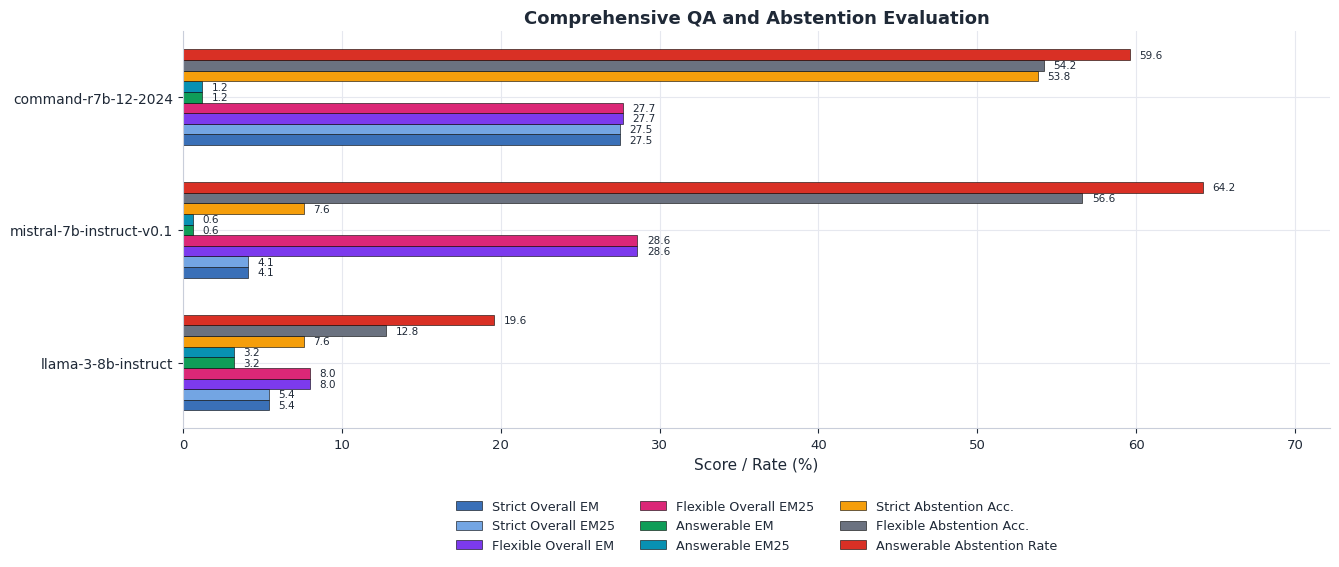

Saved: arabicaqa_rag_results/predictions/figures_strict_flexible\plot_comprehensive_strict_flexible_results_with_em_em25.png
Saved: arabicaqa_rag_results/predictions/figures_strict_flexible\plot_comprehensive_strict_flexible_results_with_em_em25.pdf


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# Paths
# ======================================================

SCORES_PATH = "arabicaqa_rag_results/predictions/final_scores_strict_and_flexible_abstention_corrected.csv"
OUT_DIR = "arabicaqa_rag_results/predictions/figures_strict_flexible"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(SCORES_PATH, encoding="utf-8-sig")

# ======================================================
# Full model names
# ======================================================

MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "llama-3-8b-instruct",
    "mistral": "mistral-7b-instruct-v0.1",
}

df["model"] = df["model"].astype(str).str.strip()
df["model"] = df["model"].replace(MODEL_DISPLAY_NAMES)

model_order = [
    "llama-3-8b-instruct",
    "mistral-7b-instruct-v0.1",
    "command-r7b-12-2024",
]

df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)
df = df.sort_values("model").reset_index(drop=True)

# ======================================================
# Required columns
# ======================================================

metrics = [
    "strict_overall_em",
    "strict_overall_em25",
    "flexible_overall_em",
    "flexible_overall_em25",
    "answerable_em",
    "answerable_em25",
    "strict_abstention_accuracy",
    "flexible_abstention_accuracy",
    "answerable_abstention_rate",
]

required_cols = ["model"] + metrics

missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise KeyError(f"Missing required columns: {missing}")

# ======================================================
# Style
# ======================================================

PRIMARY = "#3A70B8"
SECONDARY = "#73A5E3"
ACCENT = "#7C3AED"
GREEN = "#0F9D58"
RED = "#D93025"
ORANGE = "#F59E0B"
CYAN = "#0891B2"
PINK = "#DB2777"
GRAY = "#6B7280"
GRID = "#E6E8EF"
SPINE = "#C9CEDA"
TXT = "#1F2937"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": SPINE,
    "axes.labelcolor": TXT,
    "xtick.color": TXT,
    "ytick.color": TXT,
    "text.color": TXT,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 10,
    "legend.fontsize": 9.2,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.alpha": 1.0,
})

def finalize(ax):
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(SPINE)
    ax.spines["bottom"].set_color(SPINE)

def savefig(fig, name):
    png_path = os.path.join(OUT_DIR, f"{name}.png")
    pdf_path = os.path.join(OUT_DIR, f"{name}.pdf")

    fig.tight_layout()
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("Saved:", png_path)
    print("Saved:", pdf_path)

# ======================================================
# Comprehensive horizontal grouped bar chart
# ======================================================

pretty_names = {
    "strict_overall_em": "Strict Overall EM",
    "strict_overall_em25": "Strict Overall EM25",
    "flexible_overall_em": "Flexible Overall EM",
    "flexible_overall_em25": "Flexible Overall EM25",
    "answerable_em": "Answerable EM",
    "answerable_em25": "Answerable EM25",
    "strict_abstention_accuracy": "Strict Abstention Acc.",
    "flexible_abstention_accuracy": "Flexible Abstention Acc.",
    "answerable_abstention_rate": "Answerable Abstention Rate",
}

colors = [
    PRIMARY,
    SECONDARY,
    ACCENT,
    PINK,
    GREEN,
    CYAN,
    ORANGE,
    GRAY,
    RED,
]

models = df["model"].astype(str).tolist()
y = np.arange(len(models))
bar_height = 0.08

fig, ax = plt.subplots(figsize=(13.5, 6.0))

for i, metric in enumerate(metrics):
    values = df[metric].astype(float).values
    offset = (i - (len(metrics) - 1) / 2) * bar_height

    ax.barh(
        y + offset,
        values,
        height=bar_height,
        label=pretty_names[metric],
        color=colors[i],
        edgecolor="black",
        linewidth=0.4
    )

    for j, v in enumerate(values):
        ax.text(
            v + 0.6,
            y[j] + offset,
            f"{v:.1f}",
            va="center",
            ha="left",
            fontsize=7.5
        )

ax.set_yticks(y)
ax.set_yticklabels(models)

ax.set_xlabel("Score / Rate (%)")
ax.set_title("Comprehensive QA and Abstention Evaluation")

max_value = df[metrics].max().max()
ax.set_xlim(0, max(max_value + 8, 70))

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.34),
    ncol=3,
    frameon=False
)

finalize(ax)

savefig(fig, "plot_comprehensive_strict_flexible_results_with_em_em25")

In [5]:
import os
import ast
import json
import math
import pandas as pd

# ============================================================
# Clean prediction file after generation
# ============================================================

PRED_DIR = "arabicaqa_rag_results/predictions"

INPUT_FILE = "comparison_llama_mistral_command_1000.csv"
OUTPUT_FILE = "comparison_llama_mistral_command_1000_clean.csv"

input_path = os.path.join(PRED_DIR, INPUT_FILE)
output_path = os.path.join(PRED_DIR, OUTPUT_FILE)

if not os.path.exists(input_path):
    raise FileNotFoundError(f"File not found: {input_path}")

df = pd.read_csv(input_path, encoding="utf-8-sig")

print("=" * 80)
print("CLEANING PREDICTION FILE")
print("=" * 80)
print("Loaded:", input_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

# ============================================================
# Model display names
# ============================================================
# Original short keys are kept in column names for compatibility.
# Example columns:
# - predicted_answer_command
# - latency_sec_command
#
# Full names are used only for readable logging/reporting.
MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "llama-3-8b-instruct",
    "mistral": "mistral-7b-instruct-v0.1",
}

# ============================================================
# Robust parsers
# ============================================================
def parse_correct_answers(x):
    """
    Converts correct_answers to list[str].
    Handles:
    - NaN / None
    - Python list
    - stringified list: "['answer']"
    - JSON list: '["answer"]'
    - plain string answer
    """
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        # Try JSON first
        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            if str(parsed).strip():
                return [str(parsed).strip()]
        except Exception:
            pass

        # Try Python literal
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            if str(parsed).strip():
                return [str(parsed).strip()]
        except Exception:
            pass

        # Fallback: plain string
        return [s]

    return []

def parse_maybe_list(x):
    """
    Generic parser for columns such as retrieved_contexts or retrieved_doc_ids.
    """
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return x

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        return [s]

    return [x]

# ============================================================
# Clean required columns
# ============================================================
if "correct_answers" not in df.columns:
    raise KeyError("Missing column: correct_answers")

df["correct_answers"] = df["correct_answers"].apply(parse_correct_answers)

if "is_impossible" in df.columns:
    df["is_impossible"] = df["is_impossible"].astype(bool)
    df["is_answerable"] = ~df["is_impossible"]

# Optional list-like columns
for col in ["retrieved_contexts", "retrieved_doc_ids", "retrieved_chunk_ids"]:
    if col in df.columns:
        df[col] = df[col].apply(parse_maybe_list)

# ============================================================
# Detect model prediction and latency columns
# ============================================================
model_keys = [
    c.replace("predicted_answer_", "")
    for c in df.columns
    if c.startswith("predicted_answer_")
]

print("\nDetected models:")
for m in model_keys:
    display_name = MODEL_DISPLAY_NAMES.get(m, m)
    print(f" - {m} -> {display_name}")

for m in model_keys:
    pred_col = f"predicted_answer_{m}"

    if pred_col not in df.columns:
        raise KeyError(f"Missing prediction column: {pred_col}")

    df[pred_col] = df[pred_col].fillna("").astype(str)

    latency_col = f"latency_sec_{m}"
    if latency_col in df.columns:
        df[latency_col] = pd.to_numeric(df[latency_col], errors="coerce")

# ============================================================
# Integrity checks
# ============================================================
def is_empty_gold(x):
    if x is None:
        return True

    if isinstance(x, float) and math.isnan(x):
        return True

    if isinstance(x, (list, tuple)):
        return len([str(t).strip() for t in x if str(t).strip()]) == 0

    return str(x).strip() == ""

empty_mask = df["correct_answers"].apply(is_empty_gold)

print("\nGold answer integrity:")
print("Empty gold count:", int(empty_mask.sum()))
print("Empty gold %:", round(empty_mask.mean() * 100, 2))

if "is_impossible" in df.columns:
    empty_gold_but_answerable = int((empty_mask & (df["is_impossible"] == False)).sum())
    nonempty_gold_but_unanswerable = int(((~empty_mask) & (df["is_impossible"] == True)).sum())

    print("Empty gold but is_impossible=False:", empty_gold_but_answerable)
    print("Non-empty gold but is_impossible=True:", nonempty_gold_but_unanswerable)

# Error counts
print("\nPrediction error counts:")
for m in model_keys:
    pred_col = f"predicted_answer_{m}"
    display_name = MODEL_DISPLAY_NAMES.get(m, m)

    n_errors = int((df[pred_col].fillna("") == "ERROR").sum())
    print(f"{display_name}: {n_errors}")

# ============================================================
# Save clean CSV + JSONL
# ============================================================
df.to_csv(output_path, index=False, encoding="utf-8-sig")

jsonl_path = output_path.replace(".csv", ".jsonl")
df.to_json(jsonl_path, orient="records", lines=True, force_ascii=False)

print("\nSaved clean files:")
print("CSV :", output_path)
print("JSONL:", jsonl_path)

# ============================================================
# Re-read check
# ============================================================
df_check = pd.read_csv(output_path, encoding="utf-8-sig")
df_check["correct_answers"] = df_check["correct_answers"].apply(parse_correct_answers)

print("\nRe-read check:")
print(df_check["correct_answers"].apply(type).value_counts())
print("Shape:", df_check.shape)

df_check.head(3)

CLEANING PREDICTION FILE
Loaded: arabicaqa_rag_results/predictions\comparison_llama_mistral_command_1000.csv
Shape: (1000, 21)
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_command', 'latency_sec_command', 'error_command', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral']

Detected models:
 - command -> command-r7b-12-2024
 - llama -> llama-3-8b-instruct
 - mistral -> mistral-7b-instruct-v0.1

Gold answer integrity:
Empty gold count: 500
Empty gold %: 50.0
Empty gold but is_impossible=False: 0
Non-empty gold but is_impossible=True: 0

Prediction error counts:
command-r7b-12-2024: 0
llama-3-8b-instruct: 0
mistral-7b-instruct-v0.1: 0

Saved clean files:
CSV : arabicaqa_rag_results/predictions\comparison_llama_mistral_command_1000_clean.cs

,row_idx,split,document_id,question_id,question,context,correct_answers,is_impossible,is_answerable,retrieved_contexts,...,retrieved_chunk_ids,predicted_answer_command,latency_sec_command,error_command,predicted_answer_llama,latency_sec_llama,error_llama,predicted_answer_mistral,latency_sec_mistral,error_mistral
0,0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False,True,['في المملكة المتحدة. بعد ستة أشهر، كان لدى من...,...,"[4, 5, 1, 5, 3]",غير موجود في السياق.,3.673629,NaN,1995.,1.433770,NaN,غير موجود في السياق للسنة التي تم بناء الموقع ...,5.209762,NaN
1,1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False,True,['ولما أزيح التراب من فوق هرم. اكتشفت 21 مقبرة...,...,"[1, 0, 2, 4, 5]",تم اكتشاف سبع حفريات لببر نغاندونغ.,1.807783,NaN,21,1.845930,NaN,غير موجود في السياق للعدد الخاص بالحفريات التي...,5.265048,NaN
2,2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False,True,"['بورت غالب.', 'ما بعد لافوازييه.', 'البنية.',...",...,"[8, 8, 76, 4, 0]",غير موجود في السياق.,1.694605,NaN,لاعب وسط.,1.491944,NaN,غير موجود في السياق لمعرفة مركز ميو تساكتاش.,4.074893,NaN
